In [1]:
import pandas as pd
import seaborn as sns

In [12]:
df = sns.load_dataset('tips')
print(df.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [13]:
import matplotlib.pyplot as plt

C:\Users\i242544\AppData\Local\Temp\ipykernel_14060\1718298169.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill_by_day = df.groupby('day')['total_bill'].mean()


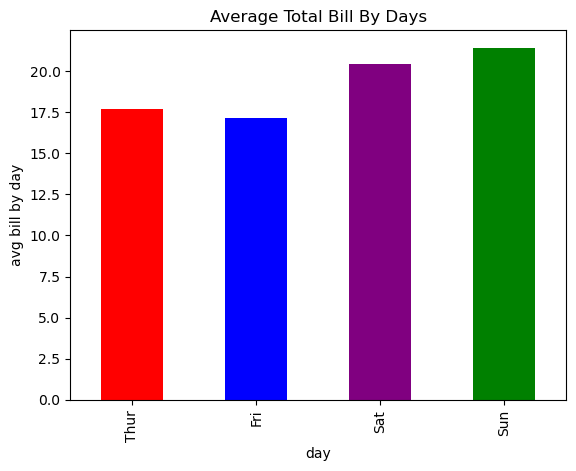

In [18]:
avg_bill_by_day = df.groupby('day')['total_bill'].mean()
avg_bill_by_day.plot(kind = 'bar', xlabel='days', ylabel = 'avg bill by day', color=['red', 'blue', 'purple','green'])
plt.title('Average Total Bill By Days')
plt.show()

0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 244, dtype: float64

C:\Users\i242544\AppData\Local\Temp\ipykernel_14060\138241822.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill_by_time = df.groupby('time')['total_bill'].mean()


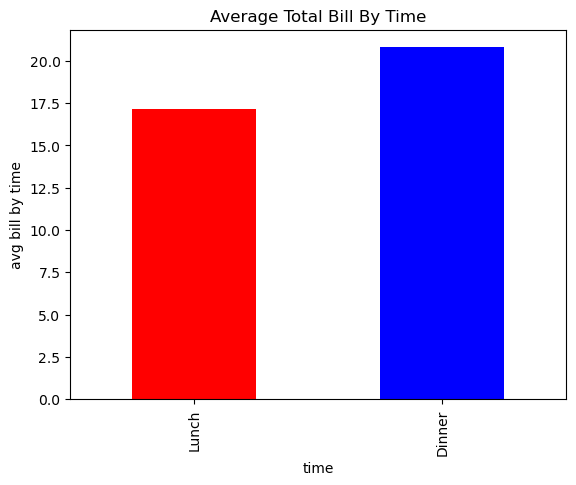

In [42]:
avg_bill_by_time = df.groupby('time')['total_bill'].mean()
avg_bill_by_time.plot(kind = 'bar', xlabel='time', ylabel = 'avg bill by time', color=['red', 'blue', 'purple','green'])
plt.title('Average Total Bill By Time')
plt.show()

C:\Users\i242544\AppData\Local\Temp\ipykernel_14060\2577947598.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'day',palette = ['purple','blue','grey' ,'violet'])


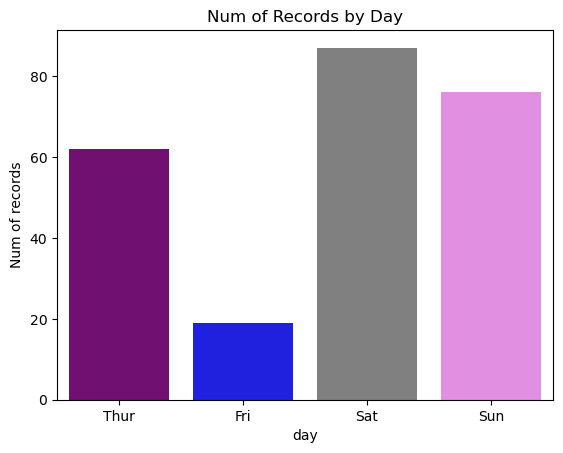

In [43]:
sns.countplot(data = df, x = 'day',palette = ['purple','blue','grey' ,'violet'])
plt.ylabel('Num of records')
plt.title('Num of Records by Day')
plt.show()

above graph shows that saturday is most common for customers enteries / records

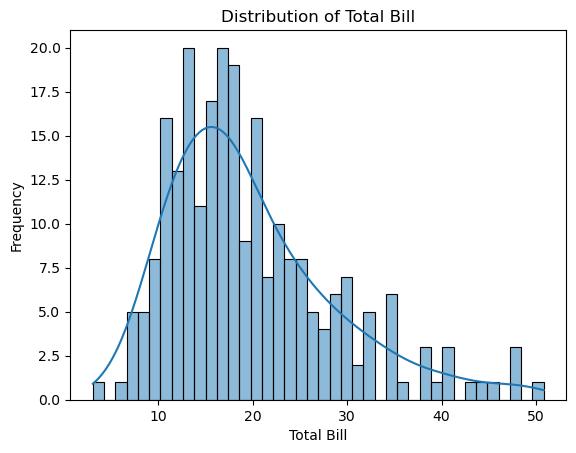

In [75]:
sns.histplot(data = df, x = 'total_bill', bins = 40, kde= True)
plt.xlabel('Total Bill')
plt.ylabel('Frequency')
plt.title('Distribution of Total Bill')
plt.show()

the above graph is right skewed and most values are concentrated to the left

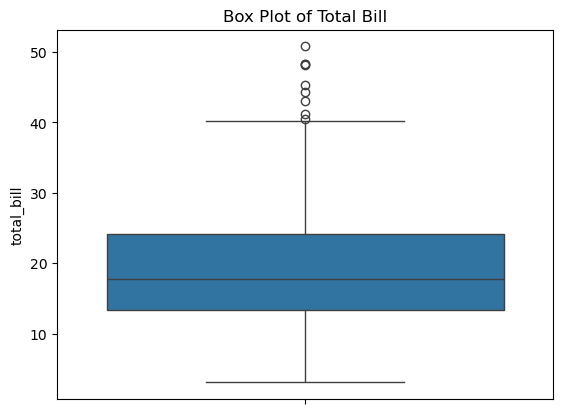

In [45]:
sns.boxplot(data = df, y = 'total_bill')
plt.title('Box Plot of Total Bill')
plt.show()

7 outliers

C:\Users\i242544\AppData\Local\Temp\ipykernel_14060\1278391387.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'sex', y = 'total_bill', palette = ['skyblue', 'pink'])


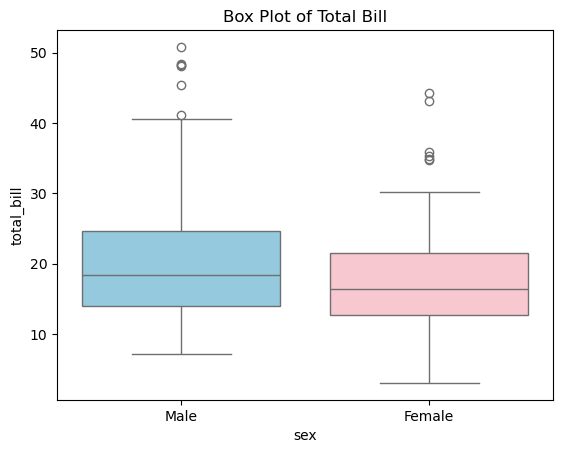

In [52]:
sns.boxplot(data = df, x = 'sex', y = 'total_bill', palette = ['skyblue', 'pink'])
plt.title('Box Plot of Total Bill')
plt.show()

4-5 outliers in male. 5-6 outliers in females

In [56]:
q1 = df['total_bill'].quantile(0.25)
q3 = df['total_bill'].quantile(0.75)
iqr = q3 - q1
lower = q1 - iqr * 1.5
upper = q3 + iqr * 1.5
outliers = df[(df['total_bill'] < lower) | (df['total_bill'] > upper)]
print('outliers: ',len(outliers))

outliers:  9


In [59]:
from scipy import stats
df['zscore'] = stats.zscore(df['total_bill'])
outliers_z = df[df['zscore'].abs() > 3] # values whose distance from mean is > 3 std
print('outliers: ',len(outliers_z))

outliers:  4


it is different because iqr method is used for skewed data (like our data is right skewed) but z score is used for normal distribution or symmetric data which is not skewed. z score is sensitive to mean and our data is skewed so z score did not find outliers accurately

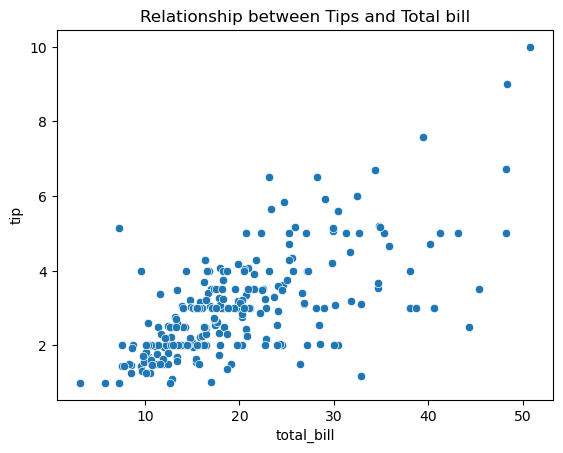

In [63]:
sns.scatterplot(data = df, x = 'total_bill', y = 'tip')
plt.title('Relationship between Tips and Total bill')
plt.show()

larger bills have larger tips => somewhat linear positive relation

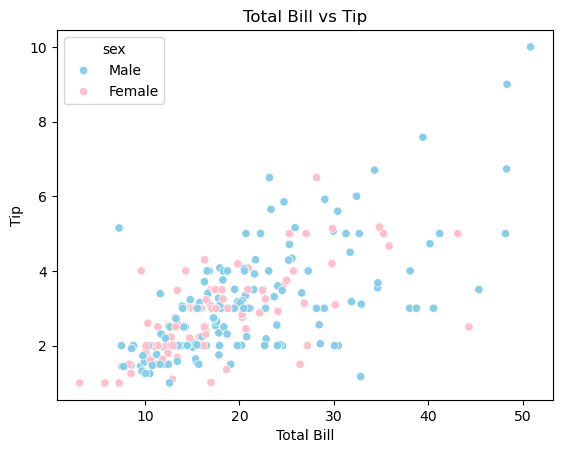

In [68]:
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex', palette = ['skyblue', 'pink'])
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Total Bill vs Tip')
plt.show()

C:\Users\i242544\AppData\Local\Temp\ipykernel_14060\4207757876.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill_day = df.groupby('day')['total_bill'].mean()


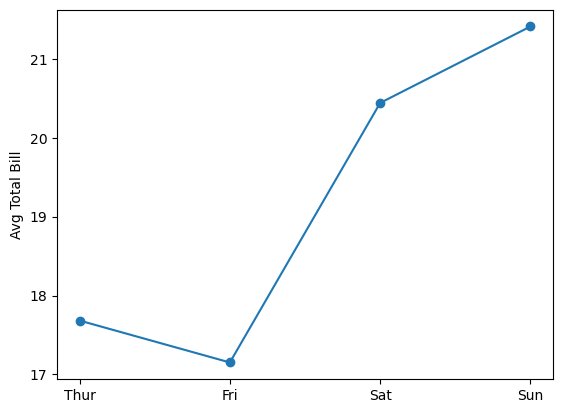

In [72]:
avg_bill_day = df.groupby('day')['total_bill'].mean()
plt.plot(avg_bill_day.index, avg_bill_day.values, marker='o')
plt.ylabel('Avg Total Bill')
plt.show()

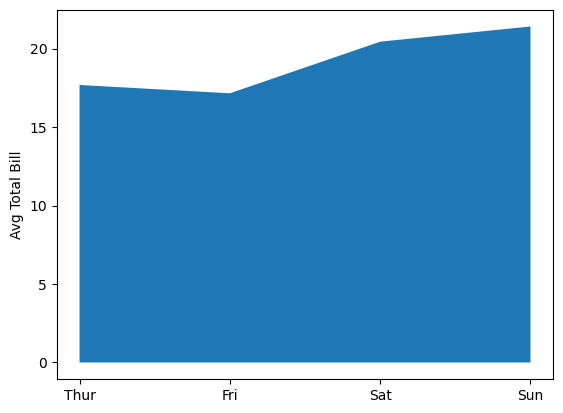

In [73]:
plt.fill_between(avg_bill_day.index, avg_bill_day.values)
plt.ylabel('Avg Total Bill')
plt.show()

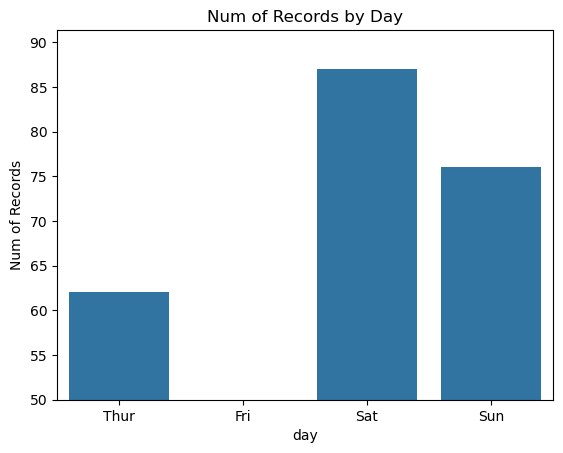

In [74]:
sns.countplot(data=df, x = 'day')
plt.ylim(bottom = 50)
plt.ylabel('Num of Records')
plt.title('Num of Records by Day')
plt.show()

We truncated y axis and lost information about one category completely. the differences between the categorical bars is huge now and thus truncated axis can be misleading or wrong